In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

In [10]:
DATA_DIR = "../Data/HAM10000_modified/images"
METADATA_PATH = "../Data/HAM10000_modified/HAM10000_metadata_modified.csv"

metadata = pd.read_csv(METADATA_PATH)

# Encode labels numerically
label_mapping = {label: idx for idx, label in enumerate(sorted(metadata["dx"].unique()))}
metadata["label"] = metadata["dx"].map(label_mapping)

num_classes = len(label_mapping)

print(metadata.head())
print(label_mapping)
print(metadata["label"].value_counts())

     lesion_id      image_id   dx    dx_type   age     sex     localization  \
0  HAM_0000000  ISIC_0025346   nv      histo  60.0    male             back   
1  HAM_0000001  ISIC_0027859  bkl      histo  70.0  female             face   
2  HAM_0000002  ISIC_0033848  mel      histo  65.0  female  lower extremity   
3  HAM_0000003  ISIC_0027886   nv  follow_up  55.0    male            trunk   
4  HAM_0000004  ISIC_0024645   nv  follow_up  40.0  female             back   

   label  
0      5  
1      2  
2      4  
3      5  
4      5  
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
label
5    5403
2     727
4     614
1     327
0     228
6      98
3      73
Name: count, dtype: int64


In [11]:
# =========================
# Define Dataset Class
# =========================

class HAMDataset(Dataset):
    """
    PyTorch Dataset for HAM10000 images.
    Returns a transformed image and its label.
    """
    def __init__(self, df, image_dir, transform=None):
        """
        df: pandas DataFrame containing 'image_id' and 'label' columns
        image_dir: path to the folder with images
        transform: torchvision transforms to apply to images
        """
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        # Returns the total number of samples
        return len(self.df)

    def __getitem__(self, idx):
        # Fetch the row for the current index
        row = self.df.iloc[idx]
        
        # Construct full image path
        img_path = os.path.join(self.image_dir, row["image_id"] + ".jpg")
        
        # Open image and convert to RGB
        image = Image.open(img_path).convert("RGB")
        
        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)
        
        # Get numeric label
        label = row["label"]
        
        return image, label

In [12]:
# =========================
# Define Transforms
# =========================

# Simple transforms for now; later you can add augmentations for robustness
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to same size
    transforms.ToTensor(),          # Convert PIL image to PyTorch tensor
])

In [ ]:
# =========================
# Outer Stratified 10-Fold Split
# =========================

# Ensure stratification to maintain class distribution in each fold
outer_skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Example: Generate train/val split for the first fold
for fold_idx, (train_idx, val_idx) in enumerate(outer_skf.split(metadata, metadata["label"])):
    if fold_idx != 0:
        continue  # Only process first fold for now
    
    # Split metadata into training and validation DataFrames
    train_df = metadata.iloc[train_idx].copy()
    val_df = metadata.iloc[val_idx].copy()
    
    # Print some info for sanity check
    print(f"Fold {fold_idx}")
    print(f"Training samples: {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")
    
    # =========================
    # Create Dataset Objects
    # =========================
    
    train_dataset = HAMDataset(train_df, image_dir=DATA_DIR, transform=transform)
    val_dataset = HAMDataset(val_df, image_dir=DATA_DIR, transform=transform)
    
    print(f"Sample train image shape: {train_dataset[0][0].shape}")
    
    # Stop after first fold for testing
    break

Fold 0
Training samples: 6723
Validation samples: 747
Sample train image shape: torch.Size([3, 224, 224])


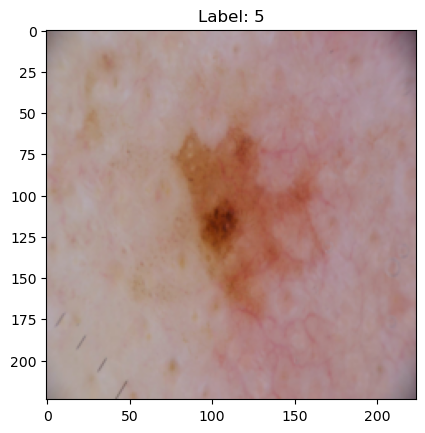

In [ ]:
## SANITY CHECK

import matplotlib.pyplot as plt

img, label = train_dataset[0]
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.show()

In [17]:
from tqdm import tqdm  # progress bar

# =========================
# Inner k-fold splits
# =========================

inner_folds = 5  # can adjust later
inner_skf = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=42)

# Prepare an array to store predicted probabilities
# Shape: (num_train_samples, num_classes)
probabilities = np.zeros((len(train_df), num_classes))

# Loop over inner folds with tqdm to track progress
for fold_num, (inner_train_idx, inner_val_idx) in enumerate(inner_skf.split(train_df, train_df["label"])):
    print(f"Inner fold {fold_num + 1}/{inner_folds}")
    
    # Split DataFrames for this inner fold
    inner_train_df = train_df.iloc[inner_train_idx].reset_index(drop=True)
    inner_val_df = train_df.iloc[inner_val_idx].reset_index(drop=True)
    
    # Create datasets
    inner_train_dataset = HAMDataset(inner_train_df, DATA_DIR, transform)
    inner_val_dataset = HAMDataset(inner_val_df, DATA_DIR, transform)
    
    # Create dataloaders
    from torch.utils.data import DataLoader
    batch_size = 16  # adjust based on your GPU memory
    train_loader = DataLoader(inner_train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(inner_val_dataset, batch_size=batch_size, shuffle=False)
    
    # -------------------------------
    # Define model
    # -------------------------------

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = models.resnet50(pretrained=False)
    # Adjust final layer to match number of classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    # -------------------------------
    # Simple training loop for this inner fold with tqdm
    # -------------------------------
    epochs = 3  # small number for now; later increase
    model.train()
    for epoch in range(epochs):
        print(f"  Epoch {epoch + 1}/{epochs}")
        for images, labels in tqdm(train_loader, desc="    Training batches"):
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # -------------------------------
    # Compute probabilities for inner validation set with tqdm
    # -------------------------------
    model.eval()
    with torch.no_grad():
        for i, (images, labels) in enumerate(tqdm(val_loader, desc="    Computing probabilities")):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
            # Map back to global indices in train_df
            start_idx = i * batch_size
            end_idx = start_idx + probs.shape[0]
            global_idx = inner_val_idx[start_idx:end_idx]
            
            probabilities[global_idx] = probs

Inner fold 1/5


c:\Users\rbraa\anaconda3\envs\mne\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rbraa\anaconda3\envs\mne\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Epoch 1/3


    Training batches: 100%|██████████| 337/337 [16:12<00:00,  2.88s/it]


  Epoch 2/3


    Training batches: 100%|██████████| 337/337 [20:10<00:00,  3.59s/it]


  Epoch 3/3


    Training batches:  94%|█████████▍| 316/337 [17:17<01:08,  3.28s/it]


KeyboardInterrupt: 

In [16]:
# =========================
# Inner k-fold splits (fast test version)
# =========================

# For testing, we reduce folds and epochs
inner_folds = 5  # fewer folds for speed
inner_skf = StratifiedKFold(n_splits=inner_folds, shuffle=True, random_state=42)

# For testing, we can use a subset of the training data
# Take 10 samples per class
from sklearn.model_selection import train_test_split

train_subset, _ = train_test_split(
    train_df, 
    train_size=10*len(label_mapping),  # 10 samples per class
    stratify=train_df["label"], 
    random_state=42
)

# Prepare array to store predicted probabilities
probabilities = np.zeros((len(train_subset), num_classes))

# Small batch size for quick GPU testing
batch_size = 4

# Loop through inner folds
for inner_train_idx, inner_val_idx in inner_skf.split(train_subset, train_subset["label"]):
    
    # Split subset into inner train/validation
    inner_train_df = train_subset.iloc[inner_train_idx].reset_index(drop=True)
    inner_val_df = train_subset.iloc[inner_val_idx].reset_index(drop=True)
    
    # Create datasets
    inner_train_dataset = HAMDataset(inner_train_df, DATA_DIR, transform)
    inner_val_dataset = HAMDataset(inner_val_df, DATA_DIR, transform)
    
    # Create dataloaders
    from torch.utils.data import DataLoader
    train_loader = DataLoader(inner_train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(inner_val_dataset, batch_size=batch_size, shuffle=False)
    
    # -------------------------------
    # Define lightweight model
    # -------------------------------

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = models.resnet18(pretrained=False)  # smaller model for test
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    # -------------------------------
    # Quick training loop for test
    # -------------------------------
    epochs = 2  # 1 epoch for speed
    model.train()
    for epoch in range(epochs):
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # -------------------------------
    # Compute probabilities for inner validation set
    # -------------------------------
    model.eval()
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
            # Map back to global indices in train_subset
            start_idx = i*batch_size
            end_idx = start_idx + probs.shape[0]
            global_idx = inner_val_idx[start_idx:end_idx]
            
            probabilities[global_idx] = probs

# -------------------------------
# Quick check
# -------------------------------
print("Probabilities shape:", probabilities.shape)
print("First 5 probability vectors:\n", probabilities[:5])

c:\Users\rbraa\anaconda3\envs\mne\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\rbraa\anaconda3\envs\mne\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\rbraa\anaconda3\envs\mne\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Probabilities shape: (70, 7)
First 5 probability vectors:
 [[0.184609   0.05705793 0.32778496 0.06415281 0.01923739 0.2837587
  0.06339918]
 [0.03554236 0.02031939 0.03218924 0.14502111 0.02368315 0.59022641
  0.15301843]
 [0.03355003 0.01875911 0.02877225 0.1807059  0.02347857 0.56776375
  0.14697042]
 [0.0648473  0.0766634  0.04809934 0.06697166 0.01033586 0.69091916
  0.04216329]
 [0.20839168 0.0588309  0.30291411 0.06808941 0.01789537 0.26997891
  0.07389961]]
